### Demand-Side Management MPC (DSMPC) HALL AND ERDIN

Copyright &copy; 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [4]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
import warnings
import casadi
import cvxpy as cp
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import colormaps
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC, CEMPC
from IPython.display import clear_output
from utils import adjust_margins

In [6]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

#### Approximate Infinite-Horizon Overtaking-Optimal Trajectory

In [7]:
# Define period length and number of periods
T, N = 96, 6

# Load parameters and create system with a long horizon
zeta_max = 40 * np.ones([T,10]); zeta_max[23::24,:] = 1
params_inf = DSMPCParams(N=N*T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max)
sys_inf = LinearSystem(params_inf.sys)

# Initialize controller
ctrl_inf = EMPC(sys_inf, params_inf.ctrl, solver='cvxpy')

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_inf, _ = ctrl_inf.solve(t=0)
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_inf = sol_x.T
u_inf = sol_u.T

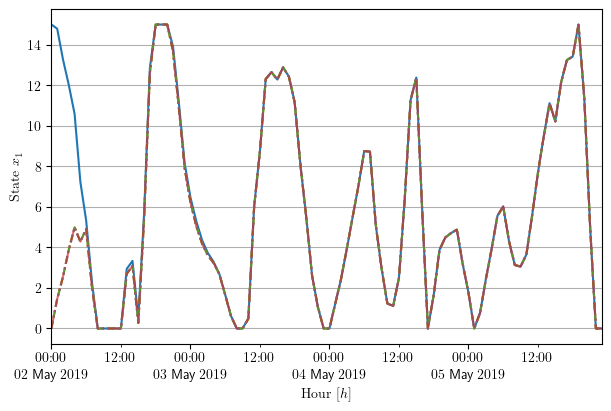

In [8]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create dates and norm vector
idx = 1
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T)])

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot trajectory
ls = ['-', '--', '--', '-.', ':', ':']
alpha = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for i in range(N):
    ax.plot(dates, x_inf[i*T:(i+1)*T,idx], ls=ls[i], alpha=alpha[i])

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{State} $x_{' + str(idx) + r'}$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=2, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
fig.savefig(f"figures/figure_trajectory_of_state_{idx}_inf_sol.pdf", bbox_inches='tight', pad_inches=0.1)

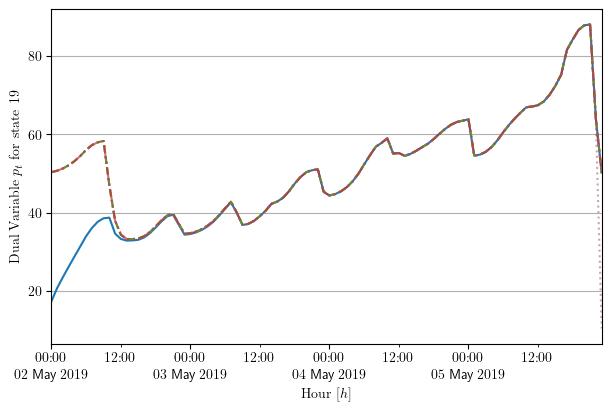

In [9]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
ls = ['-', '--', '--', '-.', ':', ':']
alpha = [1, 0.9, 0.8, 0.7, 0.6, 0.5]
for i in range(N):
    ax.plot(dates, dual_vector_inf[i*T:(i+1)*T,idx].T, ls=ls[i], alpha=alpha[i])

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dual Variable $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=20, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
fig.savefig(f"figures/figure_dual_variable_{idx}_inf_sol.pdf", bbox_inches='tight', pad_inches=0.1)

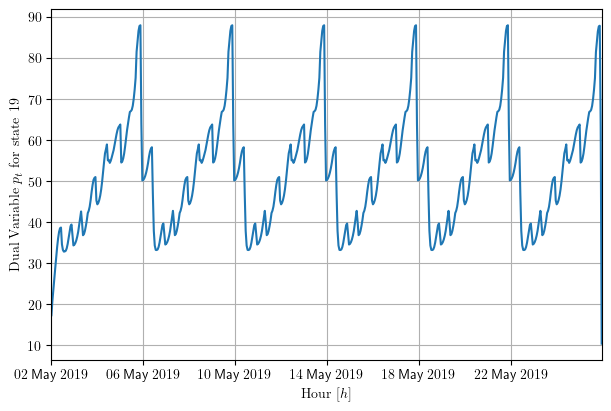

In [10]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_inf.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T*N)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
ax.plot(dates, dual_vector_inf[:,idx].T)

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dual Variable $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%d %b %Y'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(True)

# Export figure
fig.savefig(f"figures/figure_dual_variable_{idx}_inf_sol1.pdf", bbox_inches='tight', pad_inches=0.1)

In [11]:
# Check if dual variables are close
for i in range(N):
    matches = [np.allclose(dual_vector_inf[i*T:(i+1)*T,:], dual_vector_inf[j*T:(j+1)*T,:]) for j in range(6)]
    indices = [i for i, val in enumerate(matches) if val]
    print(f'Period {i} is close to period: {indices}.')

Period 0 is close to period: [0].
Period 1 is close to period: [1, 2, 3, 4].
Period 2 is close to period: [1, 2, 3, 4].
Period 3 is close to period: [1, 2, 3, 4].
Period 4 is close to period: [1, 2, 3, 4].
Period 5 is close to period: [5].


#### Simulate System Without Terminal Ingredients

##### Solve DSMPC for Varying Initial States

In [12]:
# Load parameters and create system
params = DSMPCParams(T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
sys = LinearSystem(params.sys)

# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
x = np.full((num_traj, num_steps+1, sys.n), np.nan)
u = np.full((num_traj, num_steps,   sys.m), np.nan)
x_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
u_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories', leave=False)):
    # Set initial state
    x[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=x[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x_ol[i,:] = sol_x.T
            u_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output(wait=True)

Trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

##### Solve DSMPC for Varying Horizons

In [13]:
# Setup simulation
num_steps = 48
x_0 = np.zeros((sys.n,))
horizon = [6, 9, 12, 18, 24]
num_horizon = len(horizon)

# Allocate state and input trajectories
x2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
u2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
x2_ol = np.full((num_horizon, max(horizon)+1, sys.n), np.nan)
u2_ol = np.full((num_horizon, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons', leave=False)):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    x2[i,0,:] = x_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=x2[i,t,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            x2_ol[i,:N+1,:] = sol_x.T
            u2_ol[i,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        u2[i,t,:]   = sol_u[:,0]
        x2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output(wait=True)

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

#### Simulate System With Terminal Ingredients

##### Compute Periodic Reference Trajectory

In [14]:
# Define period length
T = 96

# Define non-convex cost
gamma_1 = 5 * (1 - 2*np.random.rand(T, 10))

# Load parameters and create periodic system
zeta_max = 40 * np.ones([T,10]); zeta_max[23::24,:] = 1
params_p = DSMPCParams(N=T, T=T, zeta_max=zeta_max, zeta_min=-zeta_max, verbose=True) # gamma_1=gamma_1,
sys_p = LinearSystem(params_p.sys)

# Initialize controller
ctrl_p = CEMPC(sys_p, params_p.ctrl)

# Solve EMPC problem with free initial state
sol_u, sol_x, error_msg, dual_vars_p, stats = ctrl_p.solve(options={'eps_rel': 1E-10, 'eps_abs': 1E-10})
if error_msg != None:
    warnings.warn(error_msg)

# Save trajectory
x_p = sol_x.T
u_p = sol_u.T
dual_vector_p = np.hstack(dual_vars_p[0:ctrl_p.params.N]).T

Agents: ['27', '142', '387', '1222', '1417', '2096', '2318', '2358', '3000', '3488']
Loaded data for 10 agents from 2019-05-02 00:00:00-04:00 to 2019-05-05 23:00:00-04:00
Cost matrices: Q shape: (96, 20, 20), R shape: (96, 20, 20), c shape: (96, 1, 20)
Constraint matrices: X shape: (96, 40, 20), c_x shape: (96, 40), U shape: (96, 62, 20), c_u shape: (96, 62)
Q is positive definite for all times.
R is positive semi-definite for all times.
A is invertible for all times.
Convexification problem solved with minimal eigenvalue: 0.09997397129131139
LMIs is positive definite for all times.


##### Propagate Lagrange Multipliers

The stage Lagrangian $L_t \in \mathbb{R}$ is defined as
\begin{equation}
    L_{t}(x_t, u_t, p_{t+1}, \eta_t, \mu_t) := \eta_t\, \ell_{t}(x_t, u_t) - p_{t+1}^\top f_{t}(x_t, u_t) + \mu_t^\top g_t(x_t, u_t)
\end{equation}
with the Lagrange multipliers $\eta_t \in \mathbb{R}$, $p_0,\,p_{t+1} \in \mathbb{R}^n$ and $\mu_t \in \mathbb{R}^c$ for all $t \in \mathbb{N}_T$

The dynamics of the Lagrangian multiplier $p_t$ is given by following backward propagation
\begin{align*}
    p_t^\top &= p_{t+1}^\top \frac{\partial f_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} -\, \eta_0 \frac{\partial \ell_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} -\, \mu_t^\top \frac{\partial g_t}{\partial x}\biggl|_{(x_t^\star, u_t^\star)} \\[20pt]
    p_t^\top  &= p_{t+1}^\top A_t -\, \eta_0\, (x_t^\star){}^\top \boldsymbol{Q}_t -\, \mu_t^\top H_{x,t}
\end{align*}

which we can reformulate to obtain the forward update rule
\begin{align*}
    \Rightarrow p_{t+1}^\top &= \bigl(p_t^\top +\, \eta_0\, (x_t^\star){}^\top \boldsymbol{Q}_t +\, \mu_t^\top H_{x,t} \bigr) A_t^{-1}. \hspace{60pt}
\end{align*}

__Forward Propagation:__

In [15]:
# Allocate Lagrange multipliers p_t
p_t = np.full((T+2, sys_p.n), np.nan)
p_t[1] = dual_vector_p[0]

# Get state multipliers
state_multipliers = dual_vars_p[ctrl_p.params.N:2*ctrl_p.params.N+1]

# Propagate Lagrange multipliers p_t forward
for t in range(1,T):
    b_t = p_t[t] + 1 * ctrl_p.params.stage_cost_grad(x_p[t], u_p[t], t)[0].T + state_multipliers[t].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], t)[0].T
    p_t[t+1] = np.linalg.solve(ctrl_p.sys.f_grad(t=t)[0].T, b_t)
b_1 = p_t[-2] + 1 * ctrl_p.params.stage_cost_grad(x_p[T], u_p[0], T)[0].T + state_multipliers[T].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[T], T)[0].T
p_t[-1] = np.linalg.solve(ctrl_p.sys.f_grad(t=t)[0].T, b_1)

# Check periodicity of Lagrange multipliers
matches = np.allclose(p_t[1], p_t[-1], 1E-2)
print(f'Lagrange multipliers are {"periodic" if matches else "not periodic"}.')
print("p_diff = " + np.array2string(p_t[1] - p_t[-1], precision=1, formatter={'float_kind':lambda x: f"{x:.1e}"}))

Lagrange multipliers are periodic.
p_diff = [-2.8e-10 -9.7e-09 -4.0e-11 6.3e-09 -1.9e-11 1.5e-09 -9.9e-11 2.2e-09 -2.4e-11 -3.1e-09 -1.9e-11 -9.1e-10 -2.1e-10 -1.2e-01 -1.8e-11 3.5e-10 -9.4e-11 1.5e-09 -6.7e-11 -3.3e-09]


__Backward Propagation:__

In [16]:
# Allocate Lagrange multipliers p_t
p_t = np.full((T+2, sys_p.n), np.nan)
p_t[T+1] = dual_vector_p[0]

# Get state multipliers
state_multipliers = dual_vars_p[ctrl_p.params.N:2*ctrl_p.params.N+1]

# Propagate Lagrange multipliers p_t backwards
p_t[T] = p_t[T+1] @ ctrl_p.sys.f_grad(t=T)[0].T - 1 * ctrl_p.params.stage_cost_grad(x_p[T], u_p[t], T)[0].T - state_multipliers[T].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], T)[0].T
for t in range(T-1,0,-1):
    p_t[t] = p_t[t+1] @ ctrl_p.sys.f_grad(t=t)[0].T - 1 * ctrl_p.params.stage_cost_grad(x_p[t], u_p[t], t)[0].T - state_multipliers[t].reshape(-1) @ ctrl_p.params.h_x_grad(x_p[t], t)[0].T

# Check periodicity of Lagrange multipliers
matches = np.allclose(p_t[1], p_t[-1], 5E-2)
print(f'Lagrange multipliers are {"periodic" if matches else "not periodic"}.')
print("p_diff = " + np.array2string(p_t[1] - p_t[-1], precision=1, formatter={'float_kind':lambda x: f"{x:.1e}"}))

Lagrange multipliers are periodic.
p_diff = [-1.3e+00 1.1e-03 8.7e-01 2.7e-03 -1.6e-01 2.0e-03 -2.2e-01 2.0e-03 -2.0e-01 1.9e-03 -4.8e-01 1.7e-03 -1.5e+00 -1.0e-01 1.4e+00 3.1e-03 -7.3e-01 1.6e-03 -8.1e-01 1.5e-03]


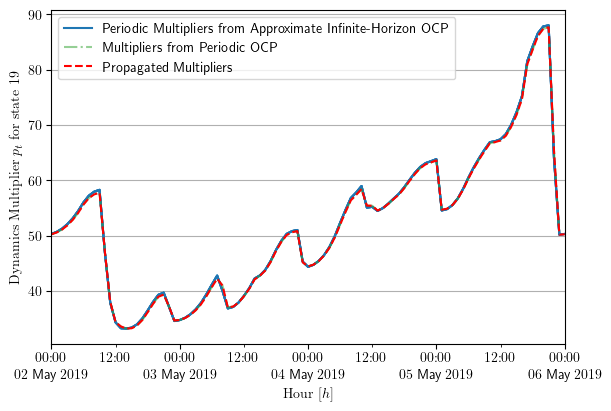

In [17]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_p.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])
dual_vector_inf = np.hstack(dual_vars_inf[0:ctrl_inf.params.N]).T

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
for i in [1,2,3,4]:
    ax.plot(dates, dual_vector_inf[i*T:(i+1)*T+1,idx].T, ls='-', color='tab:blue', label='Periodic Multipliers from Approximate Infinite-Horizon OCP' if i == 1 else None)
ax.plot(dates[:-1], dual_vector_p[:,idx].T, ls='-.', color='tab:green', alpha=0.5, label='Multipliers from Periodic OCP')
ax.plot(dates, p_t[1:,idx].T, ls='--', color='red', label='Propagated Multipliers')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{Dynamics Multiplier $p_{t}$ for state ' + str(idx) + r'}')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Plot legend
ax.legend(loc='best')

# Export figure
fig.savefig(f"figures/figure_dual_variable_{idx}_periodic_sol.pdf", bbox_inches='tight', pad_inches=0.1)

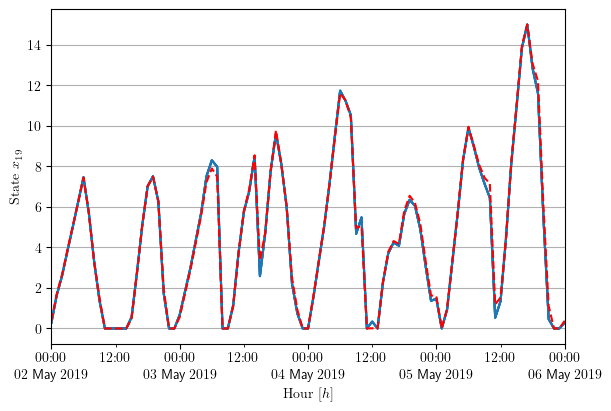

In [18]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create dates vector and get state related dual variables
idx = 19
dates = np.hstack([params_p.ctrl.start_date + pd.Timedelta(hours = h) for h in range(T+1)])

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot multipliers
for i in [1,2,3,4]:
    ax.plot(dates, x_inf[i*T:(i+1)*T+1,idx], ls='-', color='tab:blue', label='Periodic Multipliers from Infinite-Horizon Optimization' if i == 1 else None)
ax.plot(dates, x_p[:,idx].T, ls='--', color='red', label='Multipliers from Periodic Opimization')

# Add labels and title
ax.set_xlabel(r'\rmfamily{Hour} $[h]$')
ax.set_ylabel(r'\rmfamily{State} $x_{' + str(idx) + r'}$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=2, offset=0))
ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

# Set limits
plt.autoscale(enable=True, axis='x', tight=True)

# Set grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Export figure
fig.savefig(f"figures/figure_trajectory_of_state_{idx}_inf_p.pdf", bbox_inches='tight', pad_inches=0.1)

##### Solve DSMPC for Varying Initial States

In [19]:
# Initialize controller
ctrl = EMPC(sys, params.ctrl)

# Setup simulation
num_steps = 48
x_0 = [np.tile(np.array([10/4*i, 15/4*i]), 10) for i in range(5)]
num_traj  = len(x_0)

# Allocate state and input trajectories
xt = np.full((num_traj, num_steps+1, sys.n), np.nan)
ut = np.full((num_traj, num_steps,   sys.m), np.nan)
xt_ol = np.full((num_traj, params.ctrl.N+1, sys.n), np.nan)
ut_ol = np.full((num_traj, params.ctrl.N,   sys.m), np.nan)

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories', leave=False)):
    # Set initial state
    xt[i,0,:] = xi_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl.solve(t=t, x_0=xt[i,t,:], x_T=x_p[t+params.ctrl.N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt_ol[i,:] = sol_x.T
            ut_ol[i,:] = sol_u.T

        # Propagate dynamics and save input
        ut[i,t,:]   = sol_u[:,0]
        xt[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output(wait=True)

Trajectories:   0%|          | 0/5 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

c:\Users\alexe\miniconda3\envs\time-varying-rhgs\lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\alexe\AppData\Local\Temp\ipykernel_13356\1631800900.py:25: UserWarning: Solver did not achieve an optimal solution. Status: infeasible_inaccurate
  warnings.warn(error_msg)


     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

C:\Users\alexe\AppData\Local\Temp\ipykernel_13356\1631800900.py:25: UserWarning: Solver did not achieve an optimal solution. Status: infeasible
  warnings.warn(error_msg)


##### Solve DSMPC for Varying Horizons

In [20]:
# Setup simulation
num_steps = 48
x_0 = np.zeros((sys.n,))
horizon = [6, 9, 12, 18, 24]
num_horizon = len(horizon)

# Allocate state and input trajectories
xt2 = np.full((num_horizon, num_steps+1, sys.n), np.nan)
ut2 = np.full((num_horizon, num_steps,   sys.m), np.nan)
xt2_ol = np.full((num_horizon, max(horizon)+1, sys.n), np.nan)
ut2_ol = np.full((num_horizon, max(horizon),   sys.m), np.nan)

# Simulate closed-loop system
for i, N in enumerate(tqdm(horizon, desc='Horizons', leave=False)):
    # Load parameters and create system
    params2 = DSMPCParams(N=N, T=96, zeta_max=zeta_max, zeta_min=-zeta_max)
    sys2 = LinearSystem(params2.sys)

    # Initialize controller
    ctrl2 = EMPC(sys2, params2.ctrl)

    # Set initial state
    xt2[i,0,:] = x_0

    # Simulate closed-loop system
    for t in tqdm(range(num_steps),desc='   MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg, _, _ = ctrl2.solve(t=t, x_0=xt2[i,t,:], x_T=x_p[t+N,:])
        if error_msg != None:
            warnings.warn(error_msg)
            break
        
        # Save open-loop trajectory
        if t == 0:
            xt2_ol[i,:N+1,:] = sol_x.T
            ut2_ol[i,:N,:]   = sol_u.T

        # Propagate dynamics and save input
        ut2[i,t,:]   = sol_u[:,0]
        xt2[i,t+1,:] = sys2.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))
        sleep(0.01)

# Clear cell output
clear_output(wait=True)

Horizons:   0%|          | 0/5 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

c:\Users\alexe\miniconda3\envs\time-varying-rhgs\lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\alexe\AppData\Local\Temp\ipykernel_13356\3191764756.py:30: UserWarning: Solver did not achieve an optimal solution. Status: optimal_inaccurate
  warnings.warn(error_msg)


   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

   MPC:   0%|          | 0/48 [00:00<?, ?it/s]

#### Plot Results

##### Sophie's Plot

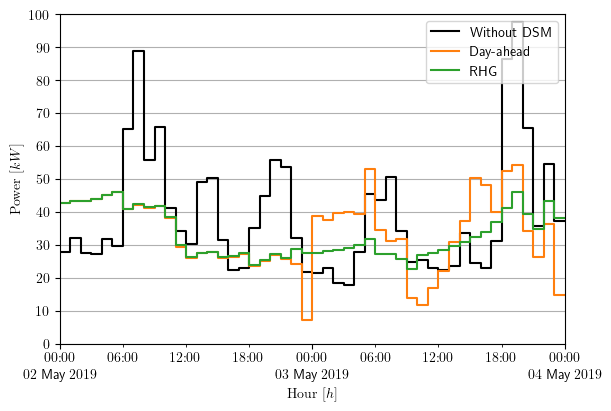

In [21]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute passive load without DSM
n_tile = np.ceil(num_steps/sys.T).astype(int)
no_dsm = np.tile(params.ctrl.consumption.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps]
no_dsm = np.hstack([no_dsm, no_dsm[-1]])

# Compute aggregate load
agg_load    = [u[i,:].sum(axis=1) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load_ol = [np.tile(u_ol[i,:].sum(axis=1), 2) + np.tile(-params.ctrl.solar.sum(axis=1) + params.ctrl.passive_load, n_tile)[:num_steps] for i in range(num_traj)]
agg_load    = [np.hstack([agg_load[t],    agg_load[t][-1]]) for t in range(num_traj)]
agg_load_ol = [np.hstack([agg_load_ol[t], agg_load_ol[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot passive load
axs.plot(dates, no_dsm, label='Without DSM', color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
axs.plot(dates, agg_load_ol[0], label='Day-ahead', color='tab:orange', linestyle='-', drawstyle='steps-post')
axs.plot(dates, agg_load[0], label='RHG', color='tab:green', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
axs.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))
axs.tick_params(axis="x", which="minor", pad=axs.xaxis.get_tick_padding())

# Set limits
axs.set_xlim([dates[0], dates[-1]])
axs.set_ylim([0, 100])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)

# Plot legend
axs.legend(loc='upper right')

# Export figure
fig.savefig("figures/figure_hall.pdf", bbox_inches='tight', pad_inches=0.1)

##### Convergence to the Overtaking-Optimal Trajectory

To observe asymptotic convergence and the Turnpike effect, we plot accumulated states and inputs for our multidimensional system. These cumulative plots should be interpreted with caution, as individual trajectories may offset one another, potentially masking the presence (or absence) of asymptotic convergence and/or the Turnpike effect. Nonetheless, they offer a useful preliminary assessment of the system's behavior. The accumulated states are defined by
\begin{equation}
    \bar{\zeta}_t := \sum_{v \in \mathcal{A}} \zeta_t^v, \qquad \bar{q}_t := \sum_{v \in \mathcal{A}} q_t^v
\end{equation}
with $\bar{x}_t := (\bar{\zeta}_t, \bar{q}_t)$ being the accumulated state vector. The accumulated inputs $\bar{u}_t$ are defined analogously.

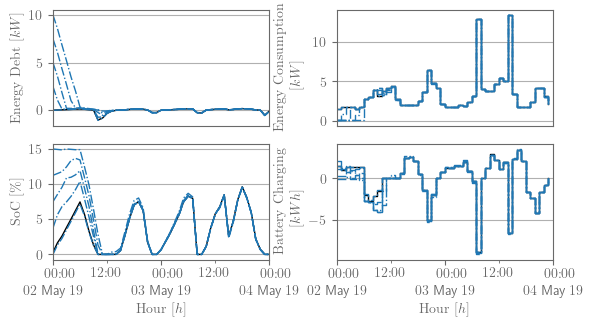

In [203]:
# Set rcParams
plt.style.use('default') # 'seaborn-v0_8-darkgrid
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.color'] = 'dimgray'
plt.rcParams['ytick.color'] = 'dimgray'
plt.rcParams['axes.edgecolor'] = 'dimgray'
plt.rcParams['axes.labelcolor'] = 'dimgray'
plt.rcParams['lines.linewidth'] = 1

# Create time vector
agent = 9
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(params.ctrl.N+1)]

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot approximate overtaking-optimal trajectories
for i in [2]:
    axs[0][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2], color='black', linestyle='-')
    axs[1][0].plot(dates, x_inf[i*T:i*T+num_steps+1,agent*2+1], color='black', linestyle='-')
    axs[0][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2], color='black', linestyle='-', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_inf[i*T:i*T+num_steps,agent*2+1], color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, x[i,:,agent*2], color='tab:blue', linestyle='-.')
    axs[1][0].plot(dates, x[i,:,agent*2+1], color='tab:blue', linestyle='-.')
    axs[0][1].plot(dates[:-1], u[i,:,agent*2], color='tab:blue', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u[i,:,agent*2+1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# # Plot trajectories with terminal constraints
# for i in range(num_traj):
#     axs[0][0].plot(dates, xt[i,:,agent*2], color='tab:orange', linestyle=':')
#     axs[1][0].plot(dates, xt[i,:,agent*2+1], color='tab:orange', linestyle=':')
#     axs[0][1].plot(dates[:-1], ut[i,:,agent*2], color='tab:orange', linestyle=':', drawstyle='steps-post')
#     axs[1][1].plot(dates[:-1], ut[i,:,agent*2+1], color='tab:orange', linestyle=':', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption}\par$\quad\qquad[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging}\par$\quad\quad[kWh]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[12])) # [6, 12, 18]
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    #ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
fig = adjust_margins(fig, width=5, height=2.5, wspace=1, hspace=0.5)
fig.savefig(f"figures/figure_asymptotic_convergence_agent_{agent+1}.pdf")

In [169]:
fig.get_constrained_layout_pads()

(0.04167, 0.04167, 0.02, 0.02)

In [171]:
fig.set_constrained_layout('constrained')

In [130]:
fig.subplotpars.bottom

np.float64(0.1435562805872757)

In [91]:
test = fig.subplotpars

In [92]:
dir(test)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'bottom',
 'hspace',
 'left',
 'right',
 'top',
 'update',
 'wspace']

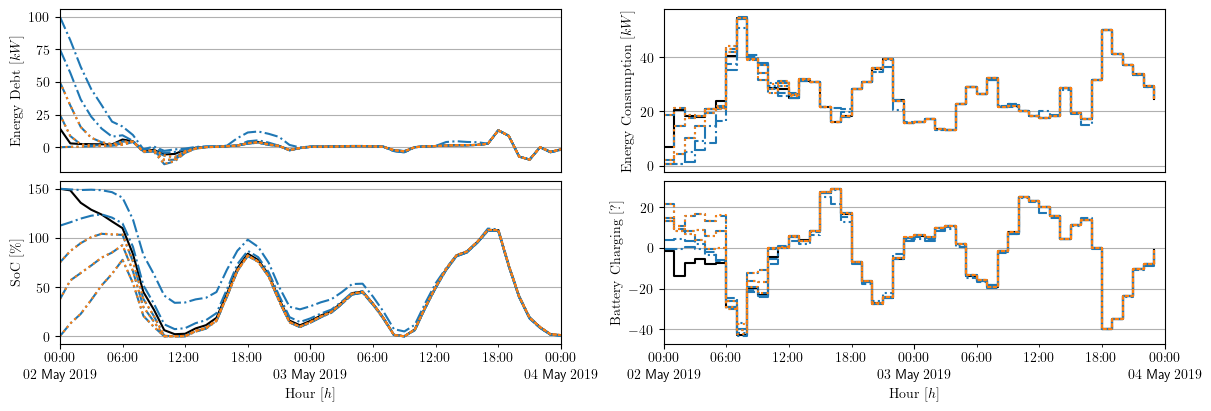

In [18]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(params.ctrl.N+1)]

# Compute accumulated states
x_acc  = np.zeros((num_traj, num_steps+1, 2))
u_acc  = np.zeros((num_traj, num_steps,   2))
xt_acc = np.zeros((num_traj, num_steps+1, 2))
ut_acc = np.zeros((num_traj, num_steps,   2))
x_acc_ol = np.zeros((num_traj, params.ctrl.N+1, 2))
u_acc_ol = np.zeros((num_traj, params.ctrl.N,   2))
for i in range(num_traj):
    x_acc[i,:,:]  = np.vstack([x[i,:,0::2].sum(axis=1), x[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:]  = np.vstack([u[i,:,0::2].sum(axis=1), u[i,:,1::2].sum(axis=1)]).T
    xt_acc[i,:,:] = np.vstack([xt[i,:,0::2].sum(axis=1), xt[i,:,1::2].sum(axis=1)]).T
    ut_acc[i,:,:] = np.vstack([ut[i,:,0::2].sum(axis=1), ut[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x_ol[i,:,0::2].sum(axis=1), x_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u_ol[i,:,0::2].sum(axis=1), u_ol[i,:,1::2].sum(axis=1)]).T
x_acc_inf = np.vstack([x_inf[:,0::2].sum(axis=1), x_inf[:,1::2].sum(axis=1)]).T
u_acc_inf = np.vstack([u_inf[:,0::2].sum(axis=1), u_inf[:,1::2].sum(axis=1)]).T
x_acc_p = np.vstack([x_p[:,0::2].sum(axis=1), x_p[:,1::2].sum(axis=1)]).T
u_acc_p = np.vstack([u_p[:,0::2].sum(axis=1), u_p[:,1::2].sum(axis=1)]).T

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot approximate overtaking-optimal trajectories
axs[0][0].plot(dates, x_acc_inf[:num_steps+1,0], color='black', linestyle='-')
axs[1][0].plot(dates, x_acc_inf[:num_steps+1,1], color='black', linestyle='-')
axs[0][1].plot(dates[:-1], u_acc_inf[:num_steps,0], color='black', linestyle='-', drawstyle='steps-post')
axs[1][1].plot(dates[:-1], u_acc_inf[:num_steps,1], color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories without terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, x_acc[i,:,0], color='tab:blue', linestyle='-.')
    axs[1][0].plot(dates, x_acc[i,:,1], color='tab:blue', linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color='tab:blue', linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# Plot trajectories with terminal constraints
for i in range(num_traj):
    axs[0][0].plot(dates, xt_acc[i,:,0], color='tab:orange', linestyle=':')
    axs[1][0].plot(dates, xt_acc[i,:,1], color='tab:orange', linestyle=':')
    axs[0][1].plot(dates[:-1], ut_acc[i,:,0], color='tab:orange', linestyle=':', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], ut_acc[i,:,1], color='tab:orange', linestyle=':', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[kWh]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M\\%d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    ax.set_xlim([dates[0], dates[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
fig.savefig("figures/figure_asymptotic_convergence_acc.pdf", bbox_inches='tight', pad_inches=0.1)

##### Compare Cost

In [19]:
# Compute cost with and without terminal constraints
data = []
for i in range(num_traj):
    cost, costt = 0, 0
    for k in range(num_steps):
        cost  += params.ctrl.stage_cost(x[i, k],  u[i, k],  t=k)[0]
        costt += params.ctrl.stage_cost(xt[i, k], ut[i, k], t=k)[0]
    
    # Append the computed costs
    data.append([cost, costt])

# Create a pandas DataFrame
columns = pd.MultiIndex.from_tuples([('Cost', 'Without'), ('Cost', 'With')])
cost_df = pd.DataFrame(data, columns=columns, index=pd.Index(range(num_traj), name="Trajectory"))
cost_df

Cost              
                 Without          With
Trajectory                            
0           30299.235613  30327.562266
1           27918.862319  27945.876044
2           27541.958577  27568.099516
3           30191.333523           NaN
4           38628.306038           NaN

##### Turnpike Plots

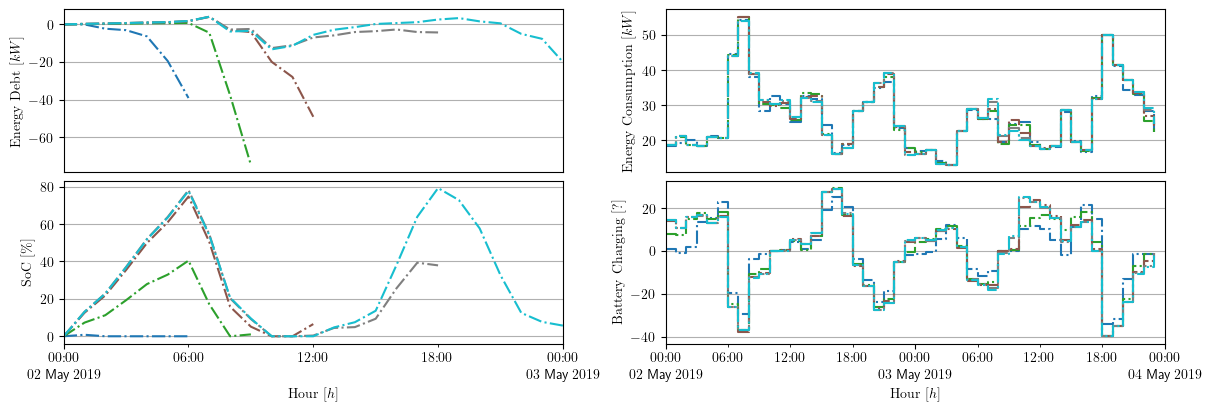

In [20]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]
dates_ol = [params2.ctrl.start_date + pd.Timedelta(hours = h) for h in range(max(horizon)+1)]

# Compute accumulated states
x_acc = np.zeros((num_horizon, num_steps+1, 2))
u_acc = np.zeros((num_horizon, num_steps,   2))
x_acc_ol = np.zeros((num_horizon, max(horizon)+1, 2))
u_acc_ol = np.zeros((num_horizon, max(horizon),   2))
for i, _ in enumerate(horizon):
    x_acc[i,:,:] = np.vstack([x2[i,:,0::2].sum(axis=1), x2[i,:,1::2].sum(axis=1)]).T
    u_acc[i,:,:] = np.vstack([u2[i,:,0::2].sum(axis=1), u2[i,:,1::2].sum(axis=1)]).T
    x_acc_ol[i,:,:] = np.vstack([x2_ol[i,:,0::2].sum(axis=1), x2_ol[i,:,1::2].sum(axis=1)]).T
    u_acc_ol[i,:,:] = np.vstack([u2_ol[i,:,0::2].sum(axis=1), u2_ol[i,:,1::2].sum(axis=1)]).T

# Create colormap
colors = colormaps['tab10'].resampled(num_horizon)

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 4), layout='constrained')

# Plot trajectories
for i, _ in enumerate(horizon):
    axs[0][0].plot(dates_ol, x_acc_ol[i,:,0], color=colors(i), linestyle='-.')
    axs[1][0].plot(dates_ol, x_acc_ol[i,:,1], color=colors(i), linestyle='-.')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color=colors(i), linestyle='-.', drawstyle='steps-post')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color=colors(i), linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[kWh]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M \\ %d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
    ax.tick_params(axis="x", which="minor", pad=ax.xaxis.get_tick_padding())

for i, ax in enumerate(axs.flatten()):
    # Set axis limits
    if i % 2 != 0:
        ax.set_xlim([dates[0], dates[-1]])
    else:
        ax.set_xlim([dates[0], dates_ol[-1]])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

# Align labels
fig.align_labels()

# Export figure
fig.savefig("figures/figure_turnpike1_acc.pdf", bbox_inches='tight', pad_inches=0.1)

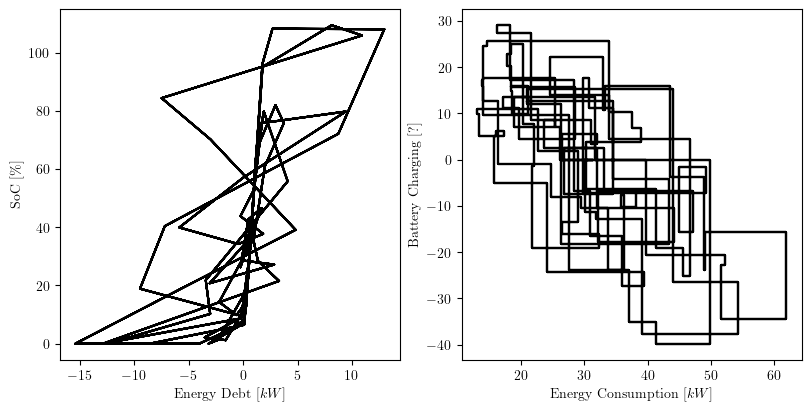

In [21]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='constrained')

# Plot trajectories
axs[0].plot(x_acc_inf[48:-48,0], x_acc_inf[48:-48,1], color='black', linestyle='-')
axs[1].plot(u_acc_inf[48:-48,0], u_acc_inf[48:-48,1], color='black', linestyle='-', drawstyle='steps-post')
# for i, _ in enumerate(horizon):
#     axs[0].plot(x_acc_ol[i,:,0], x_acc_ol[i,:,1], color='tab:blue', linestyle='-.')
#     axs[1].plot(u_acc[i,:,0], u_acc[i,:,1], color='tab:blue', linestyle='-.', drawstyle='steps-post')

# Add labels
axs[0].set_xlabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[1].set_xlabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1].set_ylabel(r'\rmfamily{Battery Charging} $[kWh]$');

# Export figure
fig.savefig("figures/figure_turnpike2_acc.pdf", bbox_inches='tight', pad_inches=0.1)